In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import random
import ast

In [2]:
df = pd.read_csv("../Data/data_jobs.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Scatter Plot

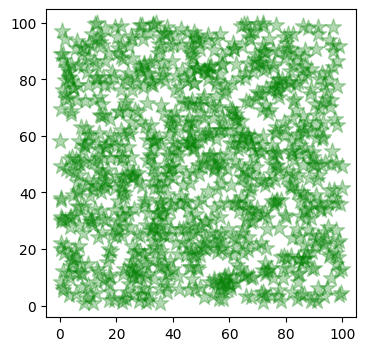

In [83]:
# Random numbers between 0 and 1 (*100 -> 0 and 100)
X_data = np.random.random(1000) * 100
Y_data = np.random.random(1000) * 100

plt.figure(figsize=(4,4))
# Takes individual data points and plots them
plt.scatter(X_data, Y_data, c="green", marker="*", s=150, alpha=0.3)
plt.show()


In [ ]:
df_exploded = df.explode('job_skills')

In [59]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(20)
skill_stats

,skill_count,median_salary
job_skills,,
sql,384849,120000.0
python,380909,125000.0
aws,145381,135000.0
azure,132527,125000.0
r,130892,119550.0
tableau,127213,111175.0
excel,127018,92500.0
spark,114609,140000.0
power bi,98147,102000.0


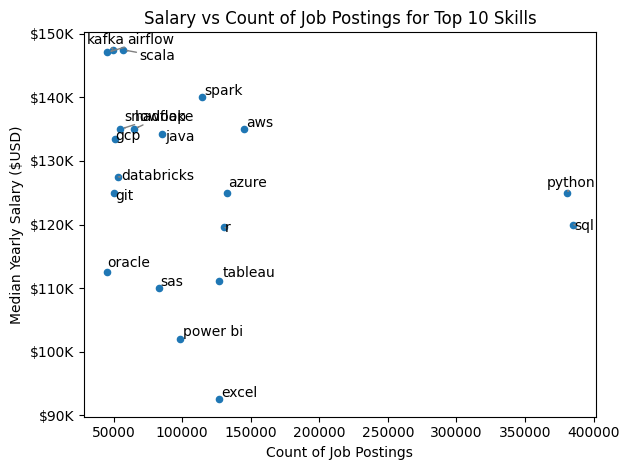

In [69]:
from adjustText import adjust_text

# fig, ax = plt.subplots()

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs Count of Job Postings for Top 10 Skills')
plt.tight_layout()
plt.show()

## Line Plot

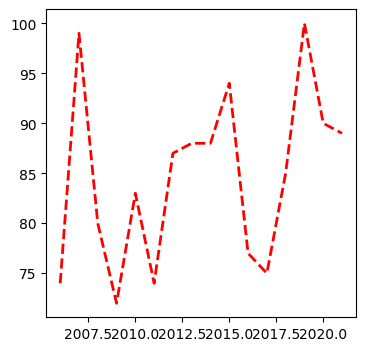

In [ ]:
years = [2006 + x for x in range(16)]
weights = [random.randint(70, 100) for _ in range(len(years))]

plt.figure(figsize=(4,4))
#plt.plot(years, weights, c="r" lw=2, linestyle="--")
plt.plot(years, weights, "r--", lw=2)

In [10]:
df.job_posted_date.head()

0   2023-06-16 13:44:15
1   2023-01-14 13:18:07
2   2023-10-10 13:14:55
3   2023-07-04 13:01:41
4   2023-08-07 14:29:36
Name: job_posted_date, dtype: datetime64[ns]

In [11]:
date_counts = df.job_posted_date.value_counts()

date_counts = date_counts.sort_index()

date_counts.index

DatetimeIndex(['2023-01-01 00:00:04', '2023-01-01 00:00:07',
               '2023-01-01 00:00:22', '2023-01-01 00:00:24',
               '2023-01-01 00:00:27', '2023-01-01 00:00:38',
               '2023-01-01 00:00:43', '2023-01-01 00:00:51',
               '2023-01-01 00:00:57', '2023-01-01 00:00:59',
               ...
               '2023-12-31 23:40:00', '2023-12-31 23:40:03',
               '2023-12-31 23:40:07', '2023-12-31 23:40:10',
               '2023-12-31 23:40:13', '2023-12-31 23:40:18',
               '2023-12-31 23:40:22', '2023-12-31 23:40:31',
               '2023-12-31 23:40:32', '2023-12-31 23:59:58'],
              dtype='datetime64[ns]', name='job_posted_date', length=607192, freq=None)

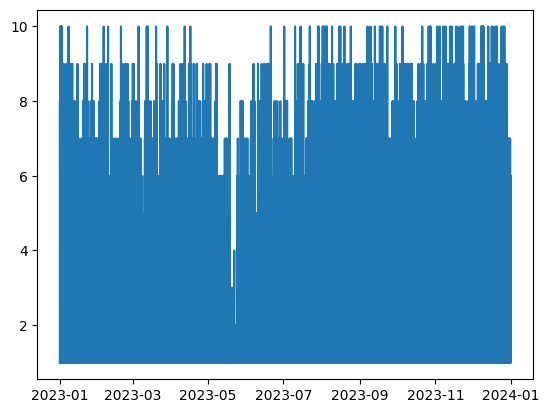

In [12]:
plt.plot(date_counts.index, date_counts)

In [13]:
df['job_posted_month'] = df['job_posted_date'].dt.month

df['job_posted_month']

0          6
1          1
2         10
3          7
4          8
          ..
785736     3
785737     3
785738     3
785739     3
785740     3
Name: job_posted_month, Length: 785741, dtype: int32

In [14]:
df['job_posted_month'] = df['job_posted_date'].dt.month
monthly_counts = df.job_posted_month.value_counts().sort_index()

monthly_counts

job_posted_month
1     91822
2     64578
3     64084
4     62919
5     52104
6     61572
7     63777
8     75162
9     62359
10    66611
11    64450
12    56303
Name: count, dtype: int64

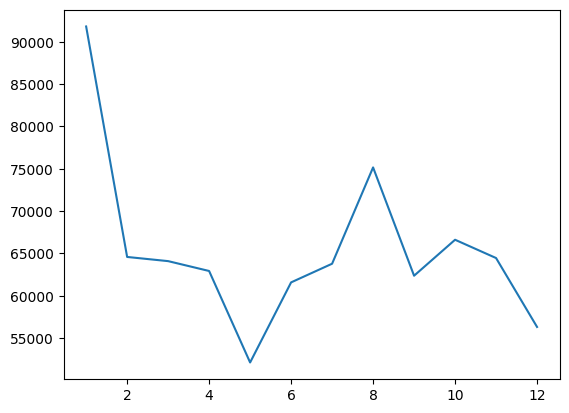

In [15]:
plt.plot(monthly_counts.index, monthly_counts)
# ~ plt.plot(monthly_counts.index, monthly_counts.values)

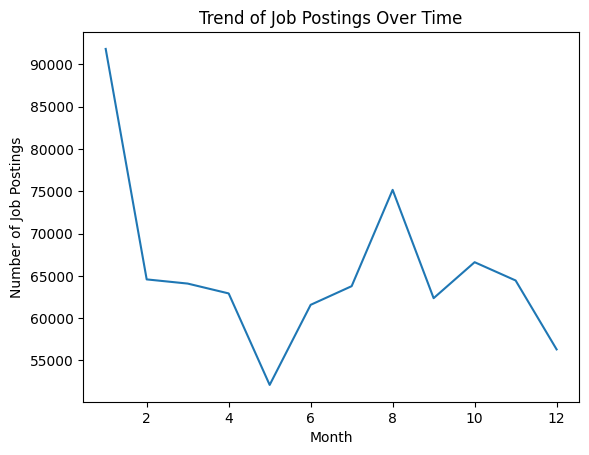

In [85]:
monthly_job_counts = df['job_posted_month'].value_counts().sort_index()
monthly_job_counts.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.title('Trend of Job Postings Over Time')
plt.show()

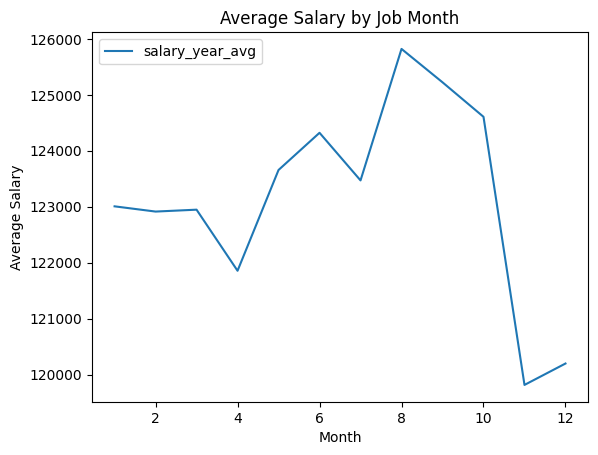

In [81]:
monthly = df.groupby('job_posted_month', as_index=False)['salary_year_avg'].mean()

monthly.sort_values('job_posted_month', inplace=True)

monthly.plot(x='job_posted_month', y='salary_year_avg', kind='line')
plt.xlabel('Month')
plt.ylabel('Average Salary')
plt.title('Average Salary by Job Month')
plt.show()

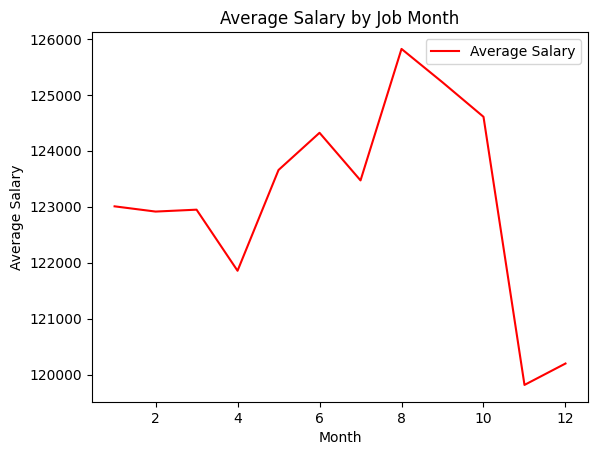

In [79]:
monthly_avg_salary = df.groupby('job_posted_month')['salary_year_avg'].mean().sort_index()
plt.plot(monthly_avg_salary.index, monthly_avg_salary.values, color='red', label='Average Salary')
plt.xlabel('Month')
plt.ylabel('Average Salary')
plt.title('Average Salary by Job Month')
plt.legend()

plt.show()

## Bar Chart

<BarContainer object of 5 artists>

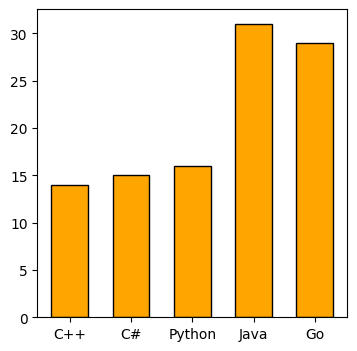

In [86]:
langs = ["C++", "C#", "Python", "Java", "Go"]
votes = [random.randint(10, 50) for _ in range(len(langs))]

plt.figure(figsize=(4,4))
plt.bar(langs, votes, color="orange", width=0.6, edgecolor="black")


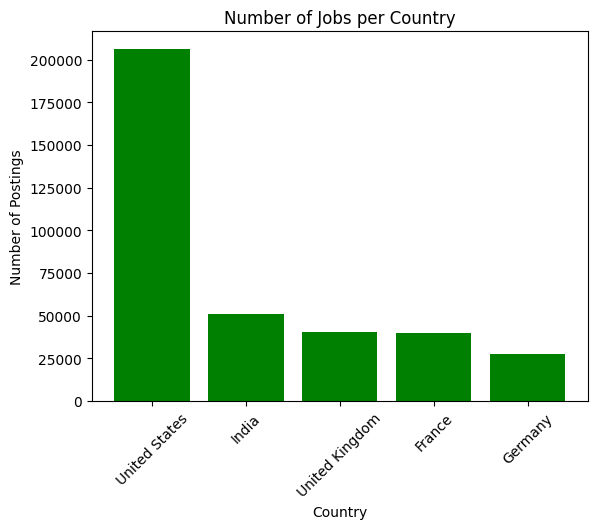

In [87]:
country_counts = df.job_country.value_counts().head(5)

plt.bar(country_counts.index, country_counts, color='green')
plt.xlabel('Country')
plt.ylabel('Number of Postings')
plt.title('Number of Jobs per Country')
plt.xticks(rotation=45)
plt.show()

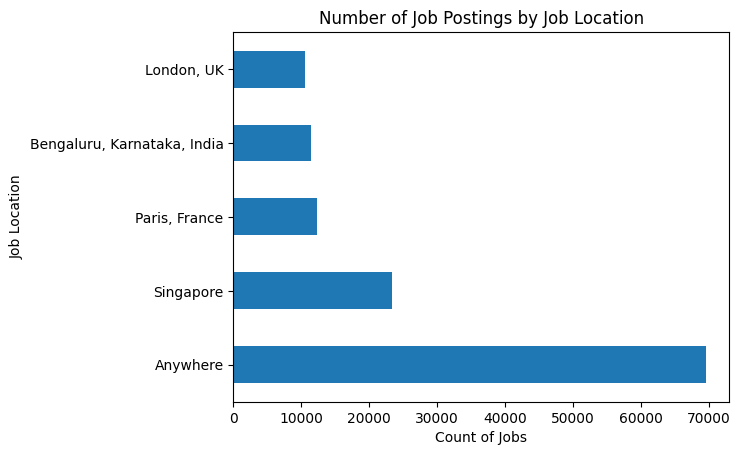

In [88]:
location_counts = df['job_location'].value_counts().head(5)
location_counts.plot(kind='barh')
plt.xlabel('Count of Jobs')
plt.ylabel('Job Location')
plt.title('Number of Job Postings by Job Location')
plt.show()

In [89]:
job_counts = df.job_title_short.value_counts()

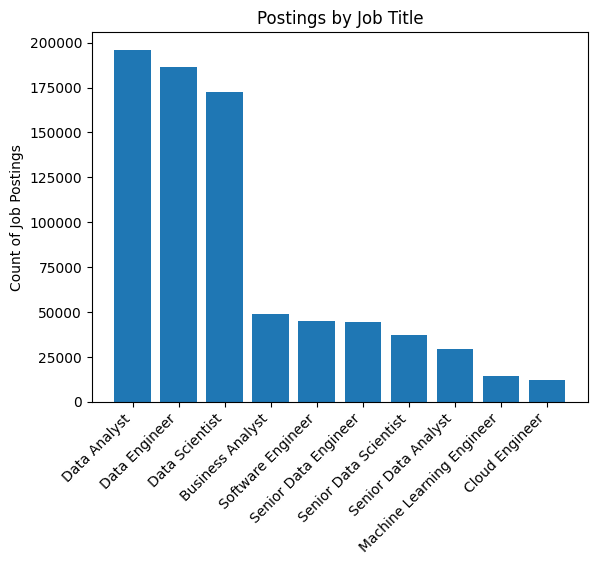

In [90]:
plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.ylabel('Count of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.show()

Text(0.5, 1.0, 'Postings by Job Title')

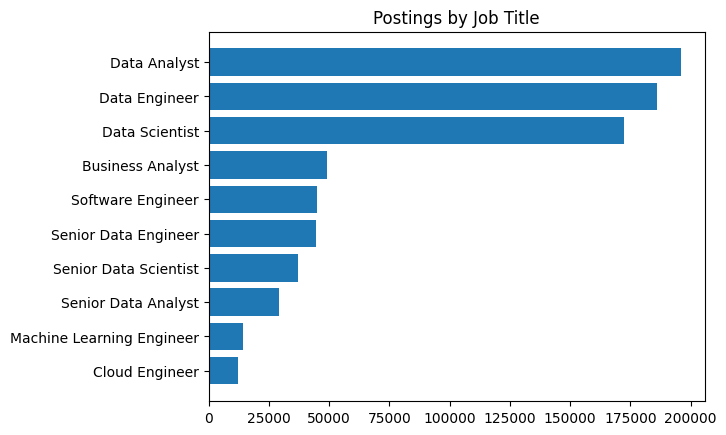

In [91]:
job_counts = job_counts.sort_values(ascending=True)
plt.barh(job_counts.index, job_counts)
plt.title('Postings by Job Title')

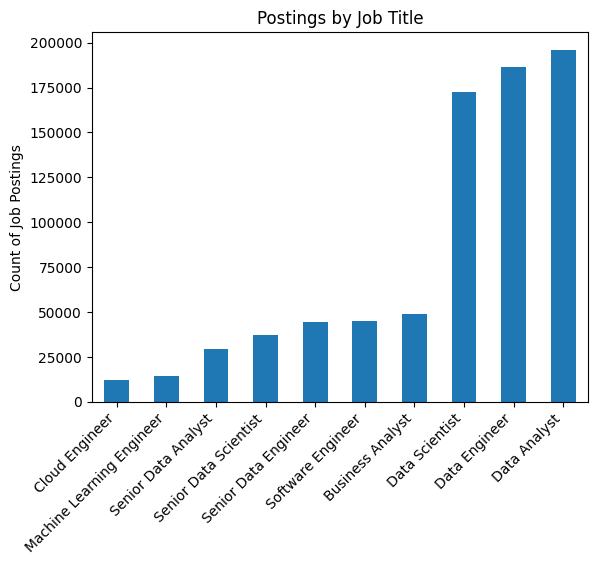

In [92]:
# Pandas + Matplotlib
job_counts.plot(kind='bar')
plt.title('Postings by Job Title')
plt.ylabel('Count of Job Postings')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.show()

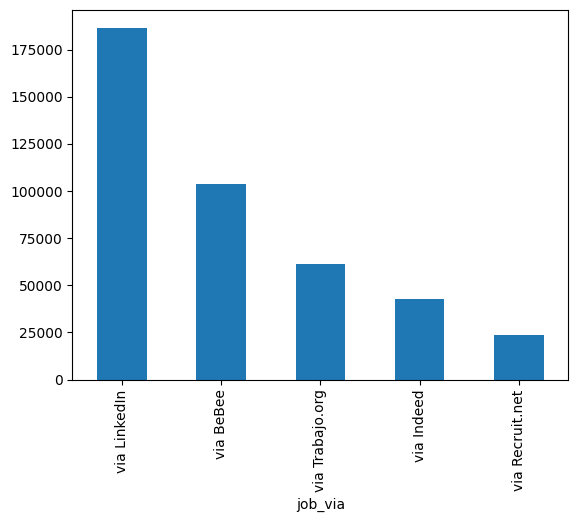

In [93]:
job_counts = df['job_via'].value_counts().head(5)
job_counts.plot(kind='bar')
plt.show()

Text(0.5, 1.0, 'Average Salary by Job Title')

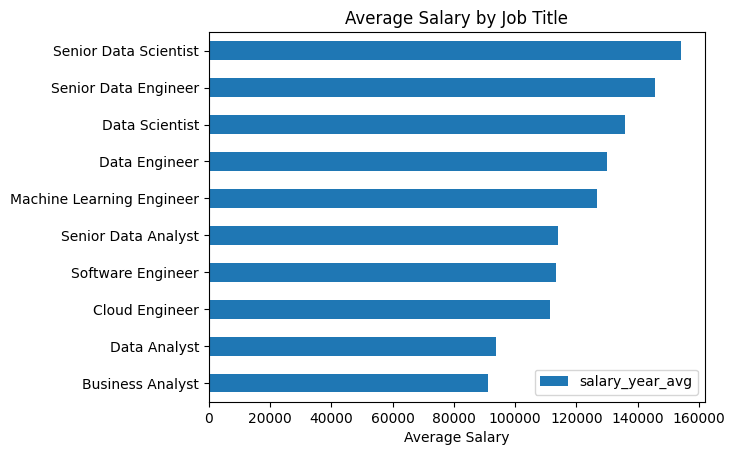

In [94]:
salaries = df.groupby('job_title_short', as_index=False)['salary_year_avg'].mean()

salaries.sort_values('salary_year_avg', inplace=True)

salaries.plot(x='job_title_short', y='salary_year_avg', kind='barh')
plt.xlabel('Average Salary')
plt.ylabel('')
plt.title('Average Salary by Job Title')

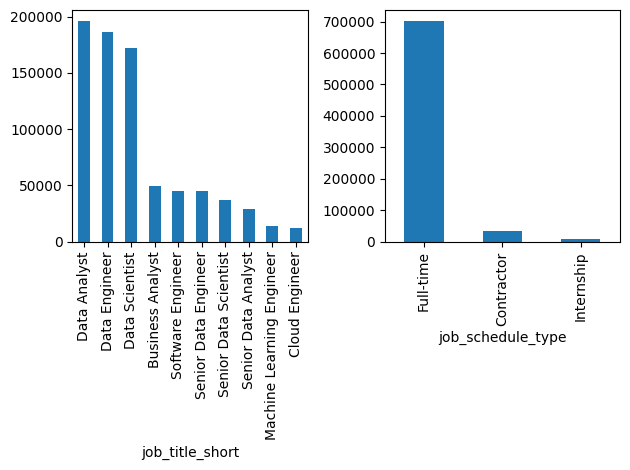

In [11]:
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])

fig.tight_layout()

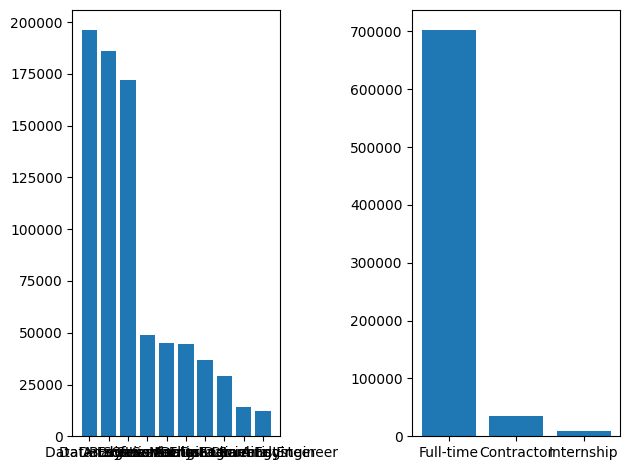

In [12]:
fig,ax = plt.subplots(1, 2)

ax[0].bar(df['job_title_short'].value_counts().index, df['job_title_short'].value_counts())
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index, df['job_schedule_type'].value_counts().head(3))
fig.tight_layout()

### Median Salary vs Data Science Jobs

In [97]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

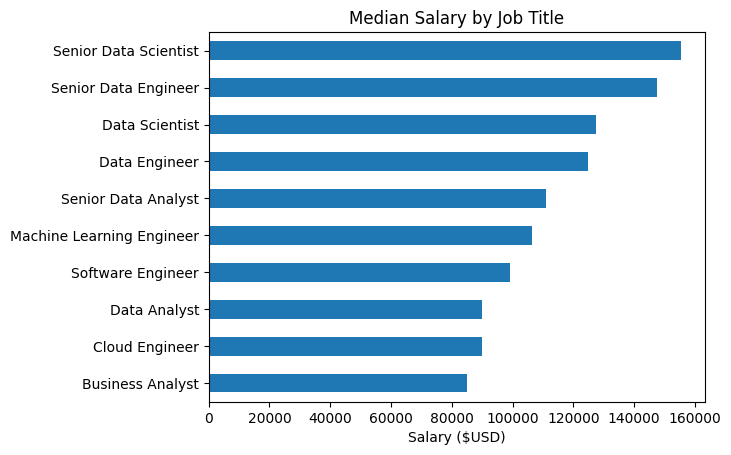

In [98]:
job_salary.plot(kind='barh')
plt.xlabel( 'Salary ($USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()

## Histogram

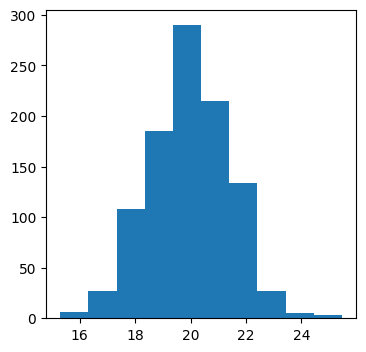

In [84]:
ages = np.random.normal(20, 1.5, 1000)

plt.figure(figsize=(4,4))
plt.hist(ages)
         #bins=[ages.min(), 19, 21, ages.max()])

plt.show()


In [70]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

Text(0, 0.5, 'Number of Jobs')

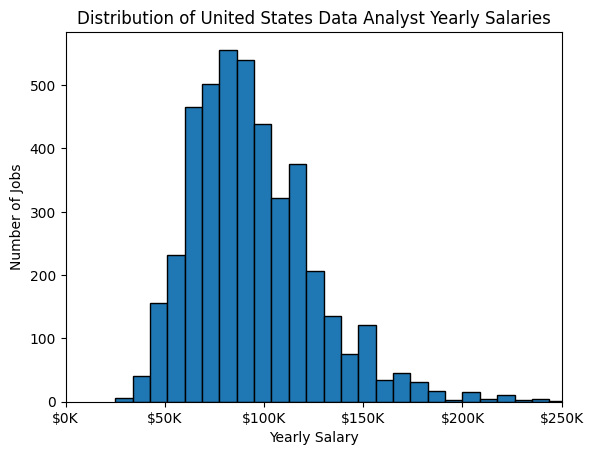

In [82]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')

## Pie Chart

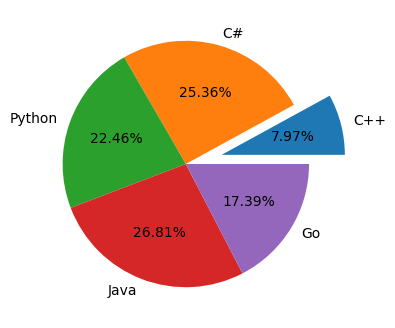

In [13]:
langs = ["C++", "C#", "Python", "Java", "Go"]
votes = [random.randint(10, 50) for _ in range(len(langs))]
explodes = [0.3, 0, 0, 0, 0]

plt.figure(figsize=(4,4))
plt.pie(votes, labels=langs, explode=explodes,
        autopct="%.2f%%")

plt.show()

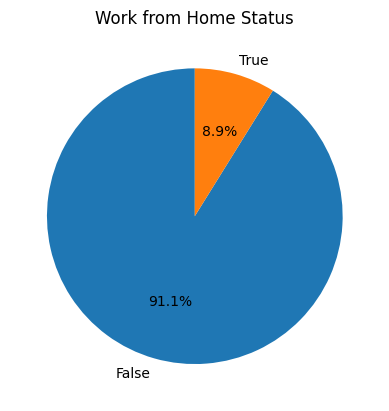

In [22]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.title('Work from Home Status')
plt.ylabel("")
plt.show()

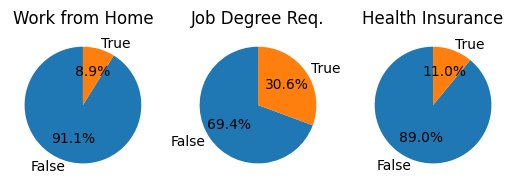

In [31]:
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)

## Box Plot

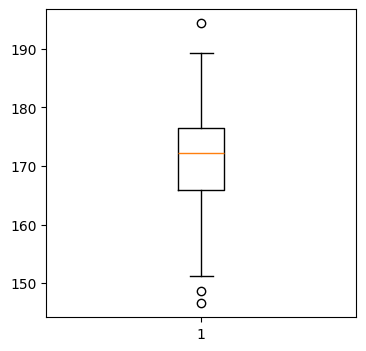

In [85]:
heights = np.random.normal(172, 8, 300)

plt.figure(figsize=(4,4))
plt.boxplot(heights)

plt.show()

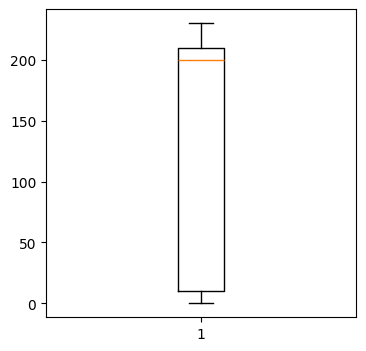

In [86]:
heights = np.random.normal(172, 8, 300)

first = np.linspace(0, 10, 25)
second = np.linspace(10, 200, 25)
third = np.linspace(200, 210, 25)
fourth = np.linspace(210, 230, 25)

data = np.concatenate([first, second, third, fourth])

plt.figure(figsize=(4,4))
plt.boxplot(data)
plt.show()

In [88]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the column for plotting
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

{'whiskers': [<matplotlib.lines.Line2D at 0x371815950>,
 'caps': [<matplotlib.lines.Line2D at 0x371815bd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x371815810>],
 'medians': [<matplotlib.lines.Line2D at 0x371815e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x371815f90>],
 'means': []}

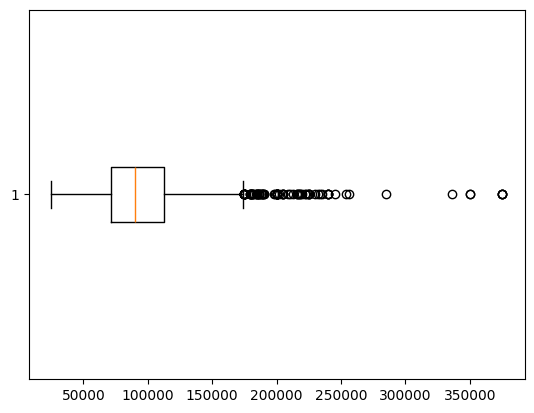

In [96]:
#df_DA_US['salary_year_avg'].plot(kind='box')
plt.boxplot(df_DA_US['salary_year_avg'], vert=False)

In [99]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

/var/folders/ps/8n41f0fn0tq35lg6t9dvxyhw0000gn/T/ipykernel_5580/4157937628.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


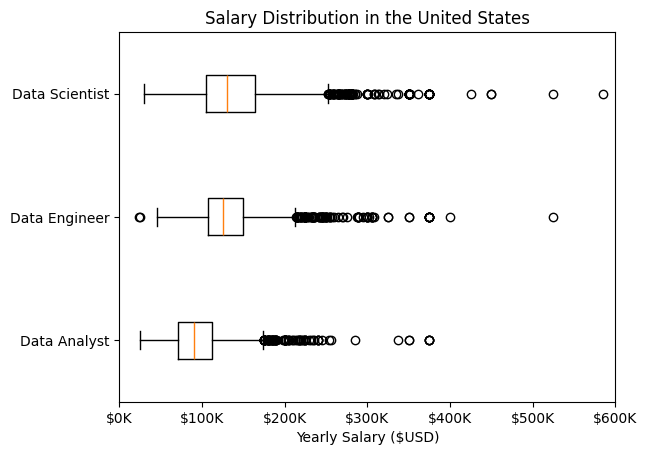

In [105]:
plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

## Plot Customization

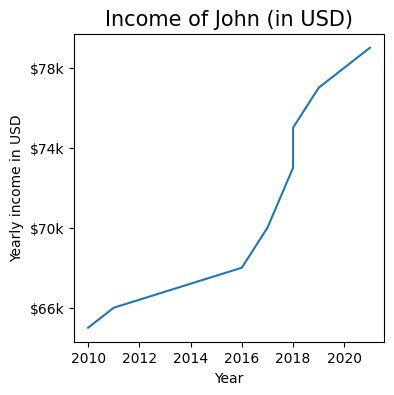

In [33]:
years = sorted([20*100 + random.randint(10, 25) for _ in range(8)])
income = sorted([random.randint(50, 80) for _ in range(len(years))])

income_ticks = list(range(50, 81, 4))

plt.figure(figsize=(4,4))
plt.title("Income of John (in USD)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Yearly income in USD")
plt.yticks(income_ticks, [f"${x}k" for x in income_ticks])
plt.plot(years, income)

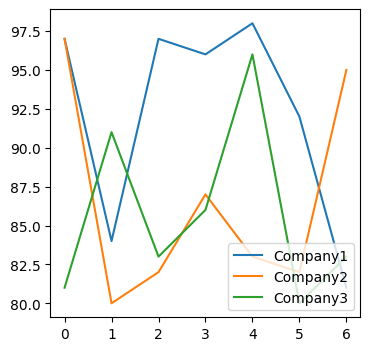

In [43]:
stock_a = [random.randint(80, 100) for _ in range(7)]
stock_b = [random.randint(80, 100) for _ in range(7)]
stock_c = [random.randint(80, 100) for _ in range(7)]

plt.figure(figsize=(4,4))
plt.plot(stock_a, label="Company1")
plt.plot(stock_b, label="Company2")
plt.plot(stock_c, label="Company3")
plt.legend(loc="lower right")

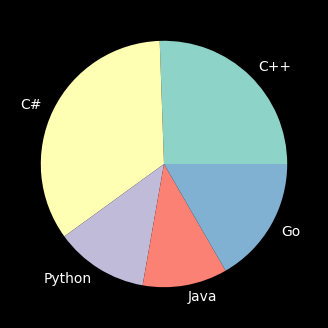

In [ ]:
style.use("dark_background")

langs = ["C++", "C#", "Python", "Java", "Go"]
votes = [random.randint(10, 50) for _ in range(len(langs))]

plt.figure(figsize=(4,4))
plt.pie(votes, labels=langs)
plt.show()

## Subplots

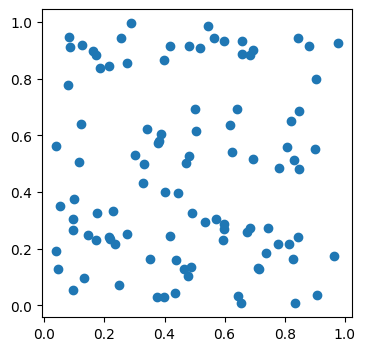

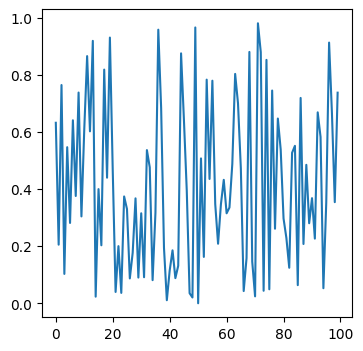

In [64]:
x1, y1 = np.random.random(100), np.random.random(100)
x2, y2 = np.arange(100), np.random.random(100)

plt.figure(1, figsize=(4,4))
plt.figure(2, figsize=(4,4))

plt.figure(1)
plt.scatter(x1, y1)

plt.figure(2)
plt.plot(x2, y2)

/var/folders/ps/8n41f0fn0tq35lg6t9dvxyhw0000gn/T/ipykernel_75863/4004679787.py:14: RuntimeWarning: divide by zero encountered in log
  axs[1, 1].plot(x, np.log(x))


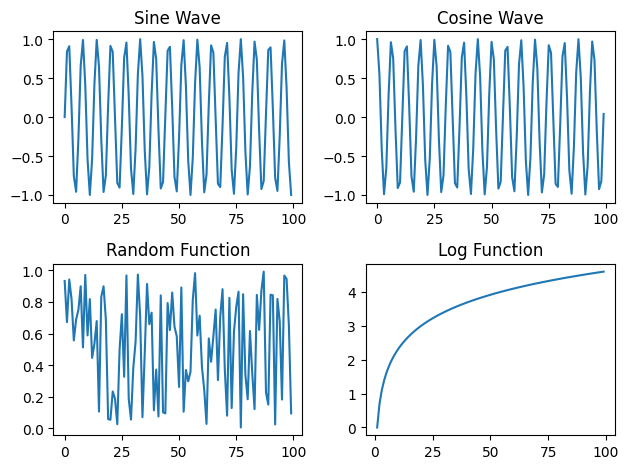

In [67]:
x = np.arange(100)

fig, axs = plt.subplots(2, 2)

axs[0, 0].plot(x, np.sin(x))
axs[0, 0].set_title("Sine Wave")

axs[0, 1].plot(x, np.cos(x))
axs[0, 1].set_title("Cosine Wave")

axs[1, 0].plot(x, np.random.random(100))
axs[1, 0].set_title("Random Function")

axs[1, 1].plot(x, np.log(x))
axs[1, 1].set_title("Log Function")

plt.tight_layout()

## 3D Plotting

Text(0.5, 0.92, '3D Plot')

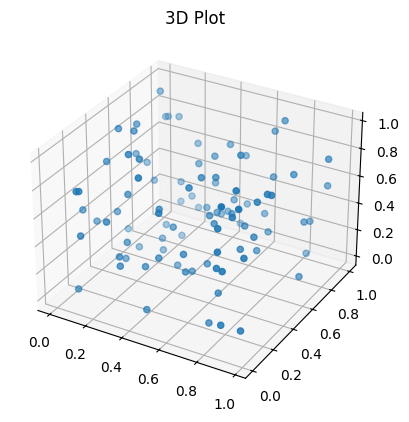

In [69]:
ax = plt.axes(projection="3d")

x = np.random.random(100)
y = np.random.random(100)
z = np.random.random(100)

ax.scatter(x, y, z)
ax.set_title("3D Plot")


Text(0.5, 0.92, '3D Plot')

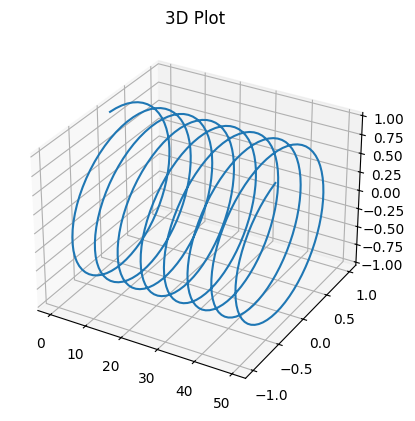

In [72]:
ax = plt.axes(projection="3d")

x = np.arange(0, 50, 0.1)
y = np.sin(x)
z = np.cos(x)

ax.plot(x, y, z)
ax.set_title("3D Plot")


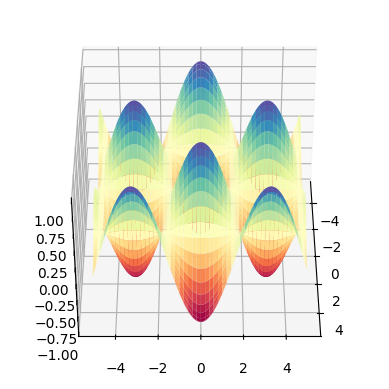

In [78]:
ax = plt.axes(projection="3d")

x = np.arange(-5, 5, 0.1)
y = np.arange(-5, 5, 0.1)

X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

ax.plot_surface(X, Y, Z, cmap="Spectral")
ax.view_init(azim=0, elev=40)



## Animation

In [81]:
heads_tails = [0, 0]

for _ in range(100000):
    heads_tails[random.randint(0, 1)] +=1
    #plt.bar(["Heads", "Tails"], heads_tails, color=["red", "blue"])
    plt.pause(0.001)
#plt.show()

KeyboardInterrupt: 